# ACE trajectories example


In [3]:
pwd

'C:\\Users\\nokni\\work\\MHDTurbPy\\Notebooks_Examples'

In [9]:
%load_ext autoreload
%autoreload 2
import os

os.chdir('C:\\Users\\nokni\\work\\MHDTurbPy\\')


from pathlib import Path
import importlib.util
from joblib import Parallel, delayed

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "functions").is_dir() and (candidate / "pyspedas").is_dir():
            return candidate
    raise RuntimeError("Could not locate MHDTurbPy root (missing functions/ and pyspedas/).")


root_dir = _find_repo_root(Path.cwd())
path_setup_file = root_dir / "functions" / "path_setup.py"
spec = importlib.util.spec_from_file_location("mhdturbpy_path_setup", path_setup_file)
if spec is None or spec.loader is None:
    raise RuntimeError(f"Could not load path setup from {path_setup_file}")
path_setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(path_setup)

root_dir = path_setup.ensure_project_paths(
    start=Path.cwd(),
    include_downloading_helpers=True,
    include_anisotropy_toolbox=True,
    include_sc_pos=True,
)


from functions import download_data as download

from functions import  calc_diagnostics as calc
from functions import  TurbPy as turb
from functions import general_functions as func
from functions import  Figures as figs
from functions import  interactive_figs
from functions.sc_pos.interactive_orbits_timeseries_plus3d import *




The autoreload extension is already loaded. To reload it, use:
  %reload_extautoreloadxt


## Build the 3D trajectory figure


In [11]:


targets = ["PSP"]

fig_3d = build_3d_figure(
    targets=targets,
    start="2025-10-01T00:00:00",
    stop="2025-12-10T00:00:00",
    step="6h",
    frame3d="HCI",
    rss_rsun=20,
    #skip_small_bodies=True,
)

fig_3d.show()


[3D] Building 3D figure in frame3d=HCI.
[3D] Left panel: AU-scale trajectories + ecliptic plane.
[3D] Right panel: Sun-zoom inset (±0.060 AU) with ballistic backmapping.
[3D] Backmapping: r_ss=20.00 R_sun, Ω=14.1844 deg/day, Vsw=[300.0, 700.0] km/s.
INFO: Obtained JPL HORIZONS location for Earth (399) [sunpy.coordinates.ephemeris]


23-Feb-26 05:34:43: Obtained JPL HORIZONS location for Earth (399)


[3D] Adding ecliptic plane patch in target frame.
[3D] Adding Earth trajectory (AU-scale).
[3D] PSP: fetching ephemeris (SPKID=-96), building trajectory and footpoints...
INFO: Obtained JPL HORIZONS location for Parker Solar Probe (spacecraft) [sunpy.coordinates.ephemeris]


23-Feb-26 05:34:45: Obtained JPL HORIZONS location for Parker Solar Probe (spacecraft)


INFO: Obtained JPL HORIZONS location for Parker Solar Probe (spacecraft) [sunpy.coordinates.ephemeris]


23-Feb-26 05:34:47: Obtained JPL HORIZONS location for Parker Solar Probe (spacecraft)


INFO: Obtained JPL HORIZONS location for Parker Solar Probe (spacecraft) [sunpy.coordinates.ephemeris]


23-Feb-26 05:34:51: Obtained JPL HORIZONS location for Parker Solar Probe (spacecraft)


In [10]:


targets = ["ACE", "WIND", "DISCOVER", "ADITYA-L1", "IMAP", 'SOLAR-1']

fig_3d = build_3d_figure(
    targets=targets,
    start="2025-10-01T00:00:00",
    stop="2025-12-10T00:00:00",
    step="6h",
    frame3d="GSE",
    rss_rsun=20,
    #skip_small_bodies=True,
)

fig_3d.show()


[3D] Building 3D figure in frame3d=GSE.
[3D] GSE mode: single geocentric panel (no Sun backmapping inset).
INFO: Obtained JPL HORIZONS location for Earth (399) [sunpy.coordinates.ephemeris]


23-Feb-26 05:31:06: Obtained JPL HORIZONS location for Earth (399)


[3D] Adding ecliptic plane patch in target frame.
[3D] ACE: fetching ephemeris (SPKID=-92), building trajectory and footpoints...
INFO: Obtained JPL HORIZONS location for ACE (spacecraft) (-92) [sunpy.coordinates.ephemeris]


23-Feb-26 05:31:07: Obtained JPL HORIZONS location for ACE (spacecraft) (-92)


[3D] WIND: fetching ephemeris (SPKID=-8), building trajectory and footpoints...
INFO: Obtained JPL HORIZONS location for Wind (spacecraft) (-8) [sunpy.coordinates.ephemeris]


...

23-Feb-26 05:31:13: Obtained JPL HORIZONS location for Aditya-L1 (-156)


[3D] IMAP: fetching ephemeris (SPKID=-43), building trajectory and footpoints...
INFO: Obtained JPL HORIZONS location for IMAP (spacecraft) (-43) [sunpy.coordinates.ephemeris]


23-Feb-26 05:31:15: Obtained JPL HORIZONS location for IMAP (spacecraft) (-43)


[3D] SOLAR-1: fetching ephemeris (SPKID=-231), building trajectory and footpoints...
INFO: Obtained JPL HORIZONS location for SWFO-L1 (spacecraft) (-231) [sunpy.coordinates.ephemeris]


23-Feb-26 05:31:16: Obtained JPL HORIZONS location for SWFO-L1 (spacecraft) (-231)


##### Build synchronized longitude/latitude time series


## MRE: first-principles stream-separation metric (step by step)

This minimal reproducible example (MRE) intentionally keeps a few assumptions fixed so the method is transparent:

- **Hardcoded/assumed in this notebook run:** `flow_dir_gse=(-1,0,0)`, constant `vsw_kms=400`, `perp_scale=0.35`, `lag_tolerance=0.5`.
- **Why this is limited:** real solar wind has time-varying speed and flow direction, and anisotropy changes with conditions.
- **How to improve with real data:** replace constants by measured `Vsw(t)`, infer local flow direction from plasma moments, and make decorrelation scales time dependent.

The solver minimizes a conservative estimate of the probability that **all** selected spacecraft observe the same stream.


INFO: Obtained JPL HORIZONS location for ACE (spacecraft) (-92) [sunpy.coordinates.ephemeris]


23-Feb-26 02:39:00: Obtained JPL HORIZONS location for ACE (spacecraft) (-92)


INFO: Obtained JPL HORIZONS location for Wind (spacecraft) (-8) [sunpy.coordinates.ephemeris]


23-Feb-26 02:39:04: Obtained JPL HORIZONS location for Wind (spacecraft) (-8)


INFO: Obtained JPL HORIZONS location for DSCOVR (spacecraft) (-78) [sunpy.coordinates.ephemeris]


...

23-Feb-26 02:39:16: Obtained JPL HORIZONS location for IMAP (spacecraft) (-43)


INFO: Obtained JPL HORIZONS location for SWFO-L1 (spacecraft) (-231) [sunpy.coordinates.ephemeris]


23-Feb-26 02:39:21: Obtained JPL HORIZONS location for SWFO-L1 (spacecraft) (-231)


[alignment v3] Worst-pair misalignment:
  Emax(t) = max_pairs [(d⊥/L⊥)^2 + (τ/τ0)^2],  p_all(t)=exp(-Emax).
  Window score = Q84(Emax) + w * median(IQR(pair p)). Lower is better.
  L_adv=0.0096 AU (225.8 Re), L_perp=0.0034 AU (79.0 Re), tau0=0.50 h.


,window_start,window_end,n_samples,coverage,alignment_metric,alignment_metric_p16,alignment_metric_p84,score_q84,p_all_q50,p_all_q84,worst_dperp_re_q84,worst_tau_h_q84
0,2025-10-03 18:59:59.999667385,2025-10-03 19:59:59.999667385,1,1.0,1.616246,1.014945,3.664561,1.540631,0.214246,0.214246,42.971111,0.557879
1,2025-10-03 20:59:59.999667385,2025-10-03 21:59:59.999667385,2,2.0,1.623106,1.022674,3.647228,1.548293,0.213131,0.213651,89.137954,0.262703
2,2025-10-03 17:59:59.999667385,2025-10-03 18:59:59.999667385,2,2.0,1.627182,1.010382,3.691816,1.550775,0.212483,0.212883,42.870276,0.560638
3,2025-10-03 21:59:59.999667385,2025-10-03 22:59:59.999667385,1,1.0,1.630637,1.027264,3.620407,1.556632,0.210845,0.210845,89.443210,0.262409
4,2025-10-03 15:59:59.999667385,2025-10-03 16:59:59.999667385,1,1.0,1.634415,1.002706,3.709419,1.557224,0.210720,0.210720,42.709141,0.562384


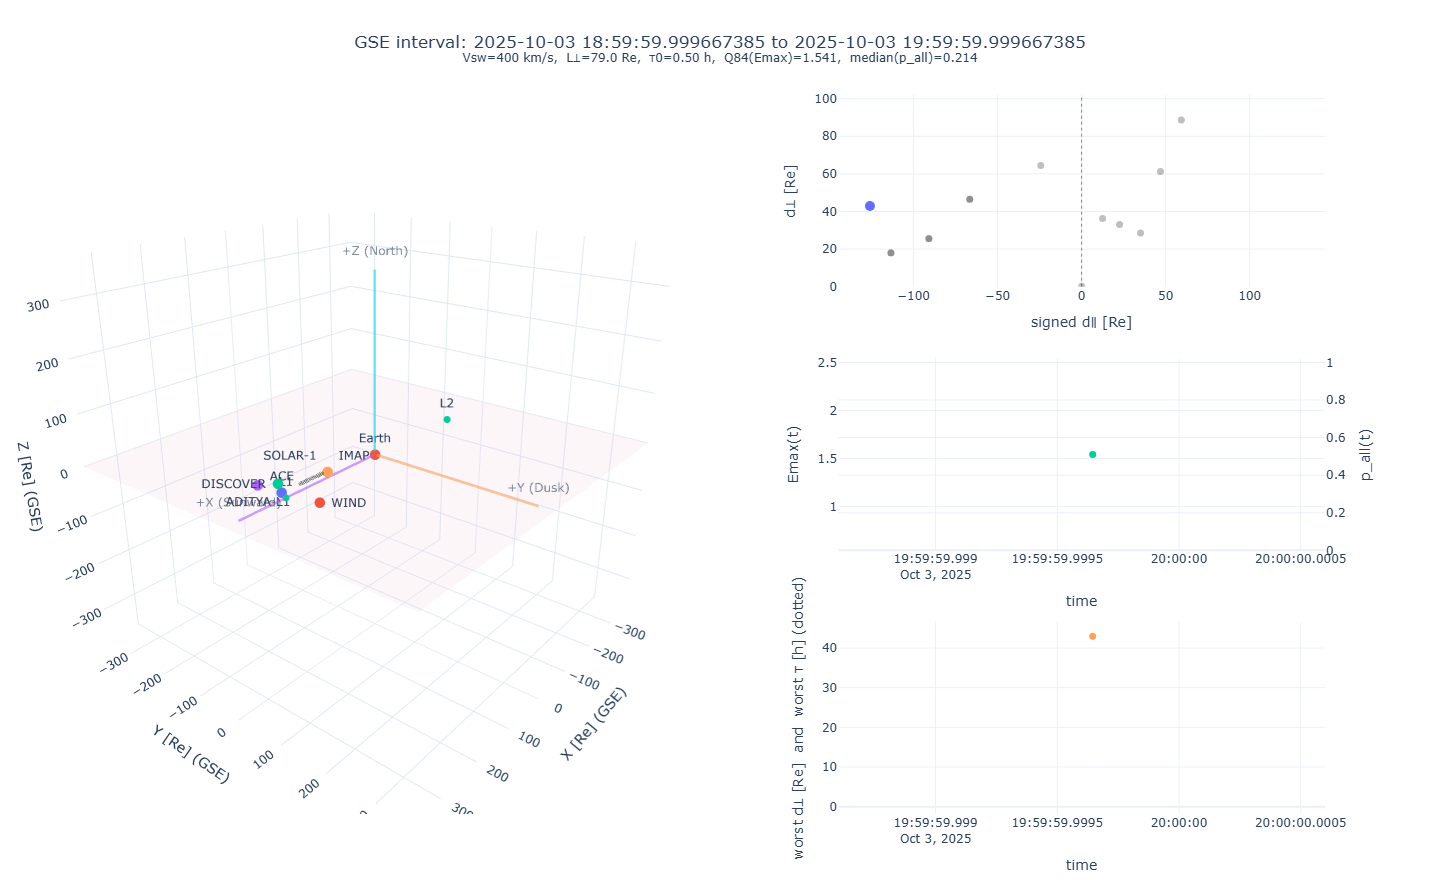

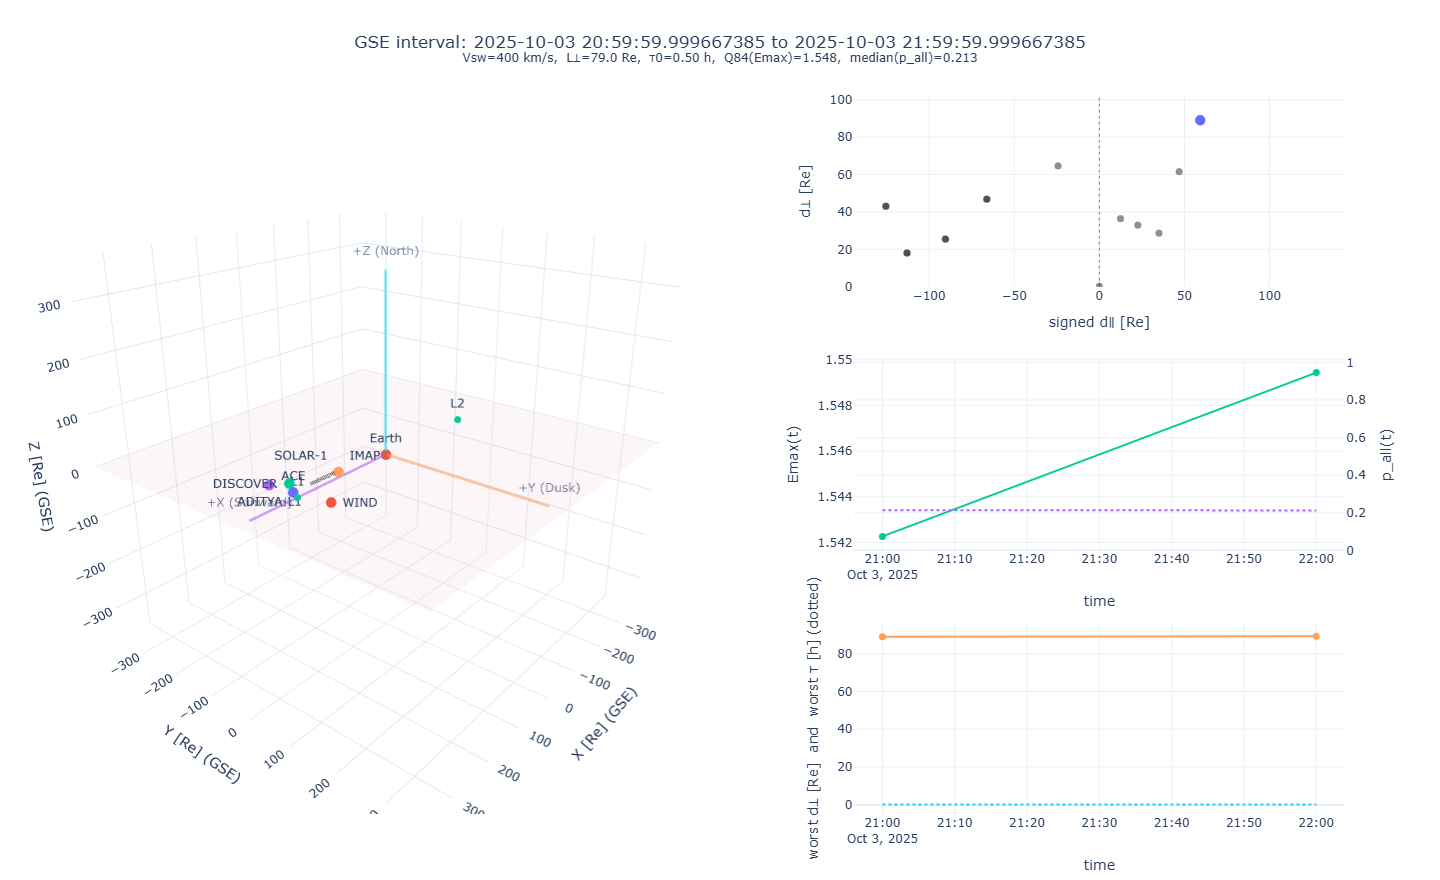

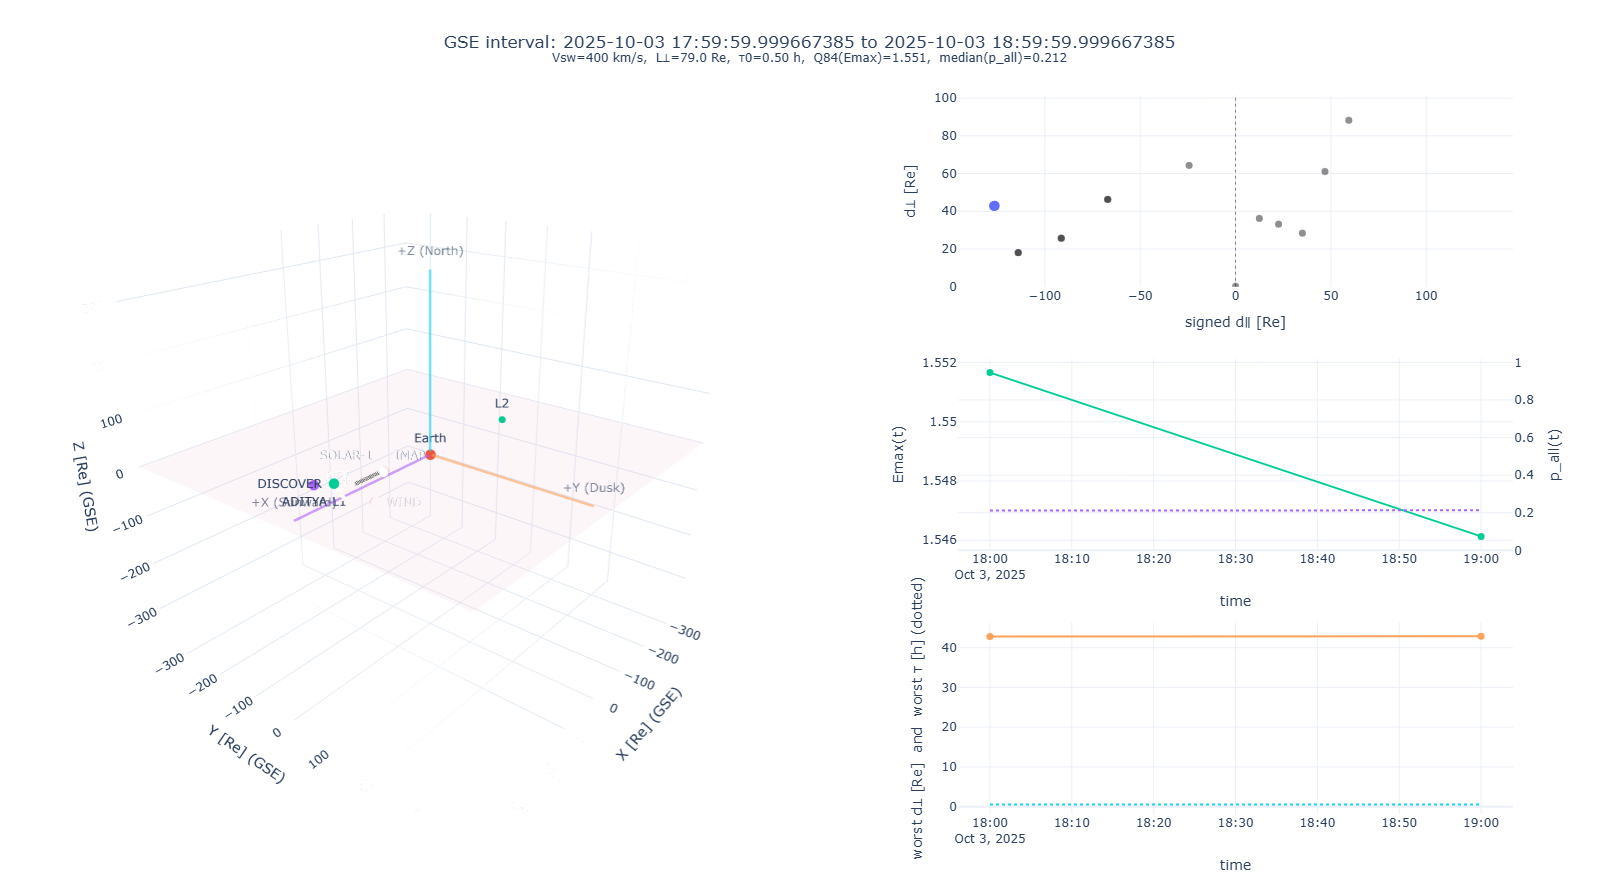

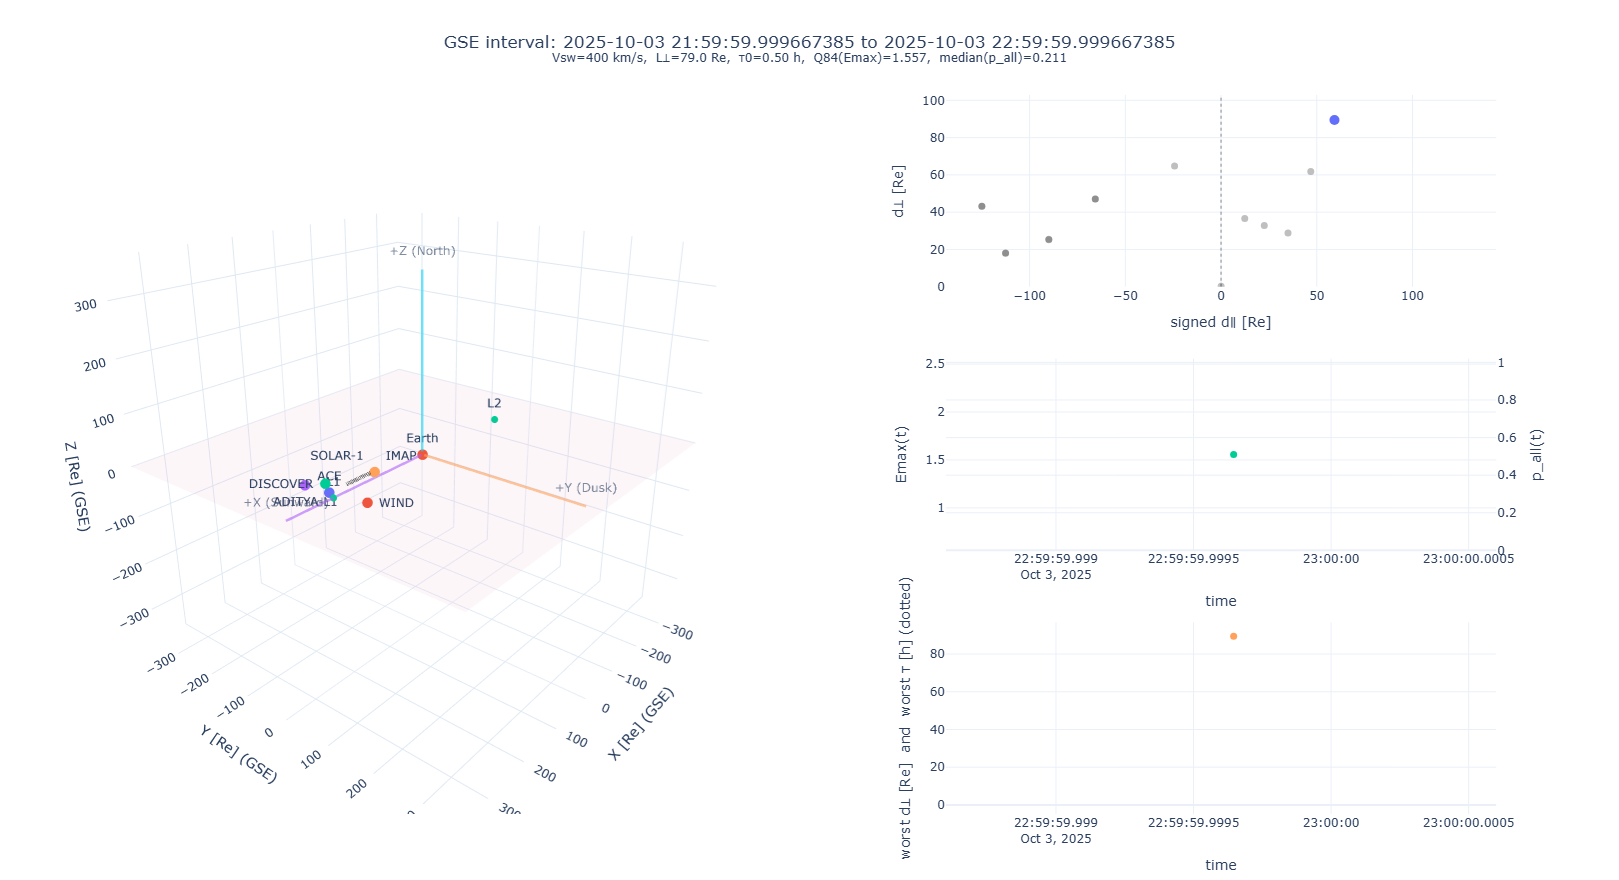

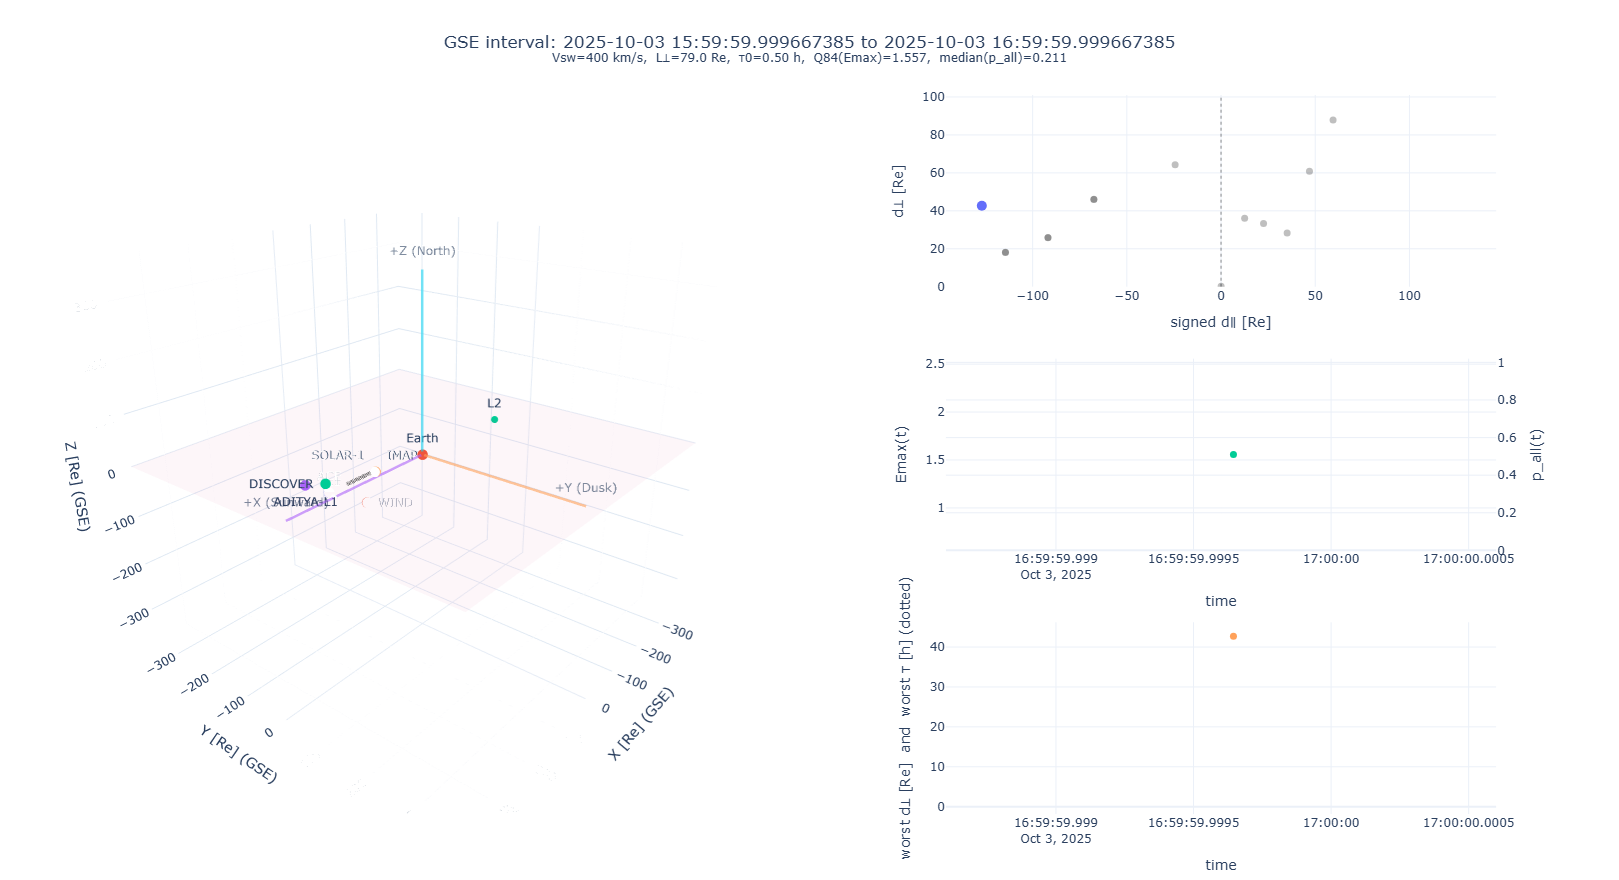

In [8]:
import pandas as pd

targets = ["WIND", "IMAP", "SOLAR-1"]
targets = ["ACE", "WIND", "DISCOVER", "ADITYA-L1", "IMAP", 'SOLAR-1']

metric_cfg = dict(
    targets=targets,
    start="2025-10-01T00:00:00",
    stop="2025-12-10T00:00:00",
    step="1H",
    window_hours=1.0,
    top_n=5,
    frame="GSE",
    flow_dir_gse=(-1.0, 0.0, 0.0),
    vsw_kms=400.0,
    perp_scale=0.35,
    lag_tolerance=0.5,
    along_weight=0.25,
    vsw_rel_unc=0.15,
    decorrelation_rel_unc=0.25,
    min_coverage=0.8,
    verbose=True,
)

scores_out = find_best_stream_aligned_intervals(**metric_cfg)
best_windows = scores_out["best"]

cols = [
    "window_start","window_end","n_samples","coverage",
    "alignment_metric","alignment_metric_p16","alignment_metric_p84",
    "score_q84","p_all_q50","p_all_q84",
    "worst_dperp_re_q84","worst_tau_h_q84",
]
display(best_windows[cols])

alignment_figs = []
for _, row in best_windows.iterrows():
    alignment_figs.append(
        plot_stream_alignment_interval(
            tracks=scores_out["tracks"],
            targets=targets,
            window_start=row["window_start"],
            window_end=row["window_end"],
            flow_hat=scores_out["flow_hat"],
            summary_row=row,
        )
    )

for fig in alignment_figs:
    fig.show()

In [12]:
import pandas as pd

targets = ["WIND", "IMAP", "SOLAR-1"]
targets = ["ACE", "WIND", "DISCOVER", "ADITYA-L1", "IMAP", 'SOLAR-1']

metric_cfg = dict(
    targets=targets,
    start="2025-10-01T00:00:00",
    stop="2025-12-10T00:00:00",
    step="1H",
    window_hours=1.0,
    top_n=5,
    frame="GSE",
    flow_dir_gse=(-1.0, 0.0, 0.0),
    vsw_kms=400.0,
    perp_scale=0.35,
    lag_tolerance=0.5,
    along_weight=0.25,
    vsw_rel_unc=0.15,
    decorrelation_rel_unc=0.25,
    min_coverage=0.8,
    verbose=True,
)

scores_out = find_best_stream_aligned_intervals(**metric_cfg)
best_windows = scores_out["best"]

cols = [
    "window_start","window_end","n_samples","coverage",
    "alignment_metric","alignment_metric_p16","alignment_metric_p84",
    "score_q84","p_all_q50","p_all_q84",
    "worst_dperp_re_q84","worst_tau_h_q84",
]
display(best_windows[cols])

alignment_figs = []
for _, row in best_windows.iterrows():
    alignment_figs.append(
        plot_stream_alignment_interval(
            tracks=scores_out["tracks"],
            targets=targets,
            window_start=row["window_start"],
            window_end=row["window_end"],
            flow_hat=scores_out["flow_hat"],
            summary_row=row,
        )
    )

for fig in alignment_figs:
    fig.show()

INFO: Obtained JPL HORIZONS location for ACE (spacecraft) (-92) [sunpy.coordinates.ephemeris]


23-Feb-26 05:40:28: Obtained JPL HORIZONS location for ACE (spacecraft) (-92)


INFO: Obtained JPL HORIZONS location for Wind (spacecraft) (-8) [sunpy.coordinates.ephemeris]


23-Feb-26 05:40:38: Obtained JPL HORIZONS location for Wind (spacecraft) (-8)


INFO: Obtained JPL HORIZONS location for DSCOVR (spacecraft) (-78) [sunpy.coordinates.ephemeris]


...

23-Feb-26 05:41:08: Obtained JPL HORIZONS location for IMAP (spacecraft) (-43)


INFO: Obtained JPL HORIZONS location for SWFO-L1 (spacecraft) (-231) [sunpy.coordinates.ephemeris]


23-Feb-26 05:41:19: Obtained JPL HORIZONS location for SWFO-L1 (spacecraft) (-231)


[alignment v3] Worst-pair misalignment:
  Emax(t) = max_pairs [(d⊥/L⊥)^2 + (τ/τ0)^2],  p_all(t)=exp(-Emax).
  Window score = Q84(Emax) + w * median(IQR(pair p)). Lower is better.
  L_adv=0.0096 AU (225.8 Re), L_perp=0.0034 AU (79.0 Re), tau0=0.50 h.


,window_start,window_end,n_samples,coverage,alignment_metric,alignment_metric_p16,alignment_metric_p84,score_q84,p_all_q50,p_all_q84,worst_dperp_re_q84,worst_tau_h_q84
0,2025-10-03 18:59:59.999667385,2025-10-03 19:59:59.999667385,1,1.0,1.616246,1.014945,3.664561,1.540631,0.214246,0.214246,42.971111,0.557879
1,2025-10-03 20:59:59.999667385,2025-10-03 21:59:59.999667385,2,2.0,1.623106,1.022674,3.647228,1.548293,0.213131,0.213651,89.137954,0.262703
2,2025-10-03 17:59:59.999667385,2025-10-03 18:59:59.999667385,2,2.0,1.627182,1.010382,3.691816,1.550775,0.212483,0.212883,42.870276,0.560638
3,2025-10-03 21:59:59.999667385,2025-10-03 22:59:59.999667385,1,1.0,1.630637,1.027264,3.620407,1.556632,0.210845,0.210845,89.443210,0.262409
4,2025-10-03 15:59:59.999667385,2025-10-03 16:59:59.999667385,1,1.0,1.634415,1.002706,3.709419,1.557224,0.210720,0.210720,42.709141,0.562384
